In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
import scanpy as sc

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

from scripts.utils import check_data, preprocess_data, save_data
from scripts.utils import DATA_PATH, ANNDATA_MAP

%load_ext autoreload
%autoreload 2

c:\Users\mayeu\anaconda3\envs\env_scvi\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
celltype="Fibroblasts"

fibroblast_cells = check_data(celltype=celltype,data_path=DATA_PATH)
if fibroblast_cells is None:
    fibroblast_cells = preprocess_data(celltype=celltype, with_subsets_config=True, n_neighbors=15, n_comps=100, random_state=42, verbose=False)
    save_data(data=fibroblast_cells, data_path=f"{DATA_PATH}\\{ANNDATA_MAP[celltype]}")

In [9]:
np.unique(fibroblast_cells.obs["cellstates_tme"])

array(['CAF1', 'CAF2', 'CAF3', 'Resident fibroblasts 1',
       'Resident fibroblasts 2'], dtype=object)

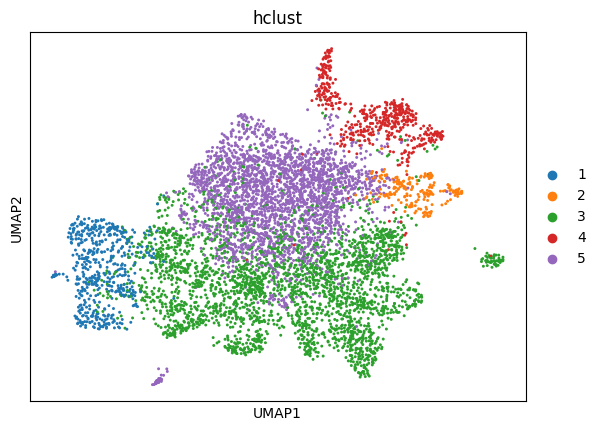

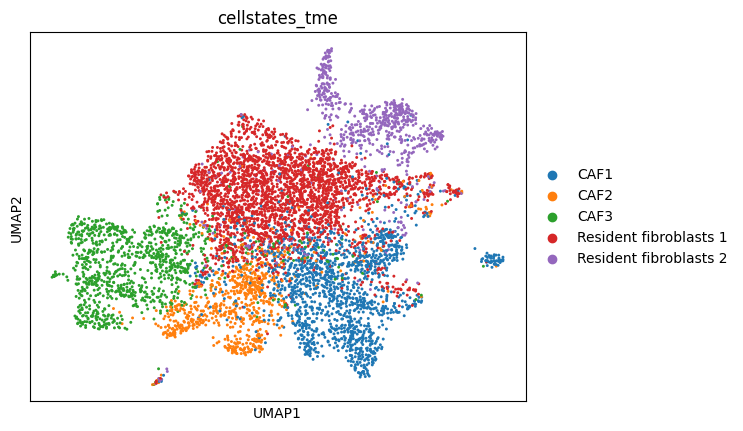

In [ ]:
# ── 1. Repartir de tes données normalisées SCT ───────────────────────────────
# cells.X contient déjà le SCT normalisé
adata_sct = fibroblast_cells.copy()

# ── 2. PCA sur les données SCT ───────────────────────────────────────────────
sc.pp.pca(adata_sct, n_comps=50)
X = adata_sct.obsm["X_pca"]

# ── 3. Clustering hiérarchique ───────────────────────────────────────────────
linkage_matrix = sch.linkage(X, method="ward")
labels = fcluster(linkage_matrix, t=5, criterion="maxclust")
adata_sct.obs["hclust"] = labels.astype(str)

# ── 4. Visualiser ────────────────────────────────────────────────────────────
sc.pl.umap(adata_sct, color="hclust")
sc.pl.umap(adata_sct, color="cellstates_tme")

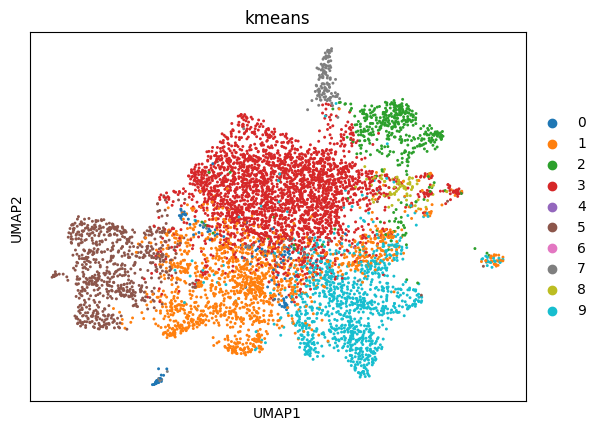

In [ ]:
adata = adata_sct
# ── 1. PCA ───────────────────────────────────────────────────────────────────
sc.pp.pca(adata, n_comps=50)
X = adata.obsm["X_pca"]

# ── 2. KMeans ────────────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=10, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X)
adata.obs["kmeans"] = labels.astype(str)

# ── 3. Visualiser ────────────────────────────────────────────────────────────
sc.pl.umap(adata, color="kmeans")

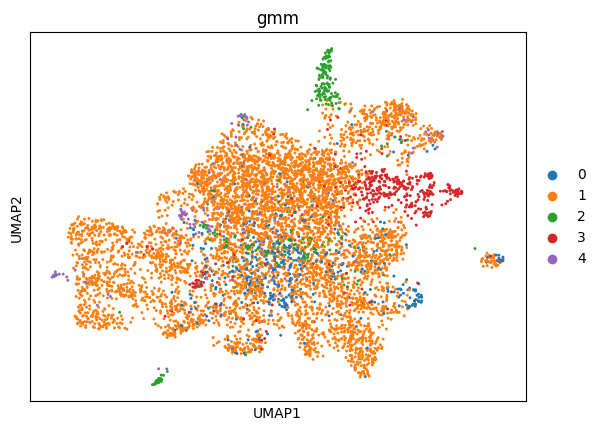

In [ ]:
# ── 1. PCA ───────────────────────────────────────────────────────────────────
sc.pp.pca(adata, n_comps=50)
X = adata.obsm["X_pca"]

# ── 2. GMM ───────────────────────────────────────────────────────────────────
gmm = GaussianMixture(n_components=5, covariance_type="full", random_state=42)
gmm.fit(X)
labels = gmm.predict(X)
proba = gmm.predict_proba(X)  # probabilité d'appartenance à chaque cluster

adata.obs["gmm"] = labels.astype(str)

# ── 3. Visualiser ────────────────────────────────────────────────────────────
sc.pl.umap(adata, color="gmm")

Clusters trouvés : 3
Cellules outliers : 2310 (34.5%)


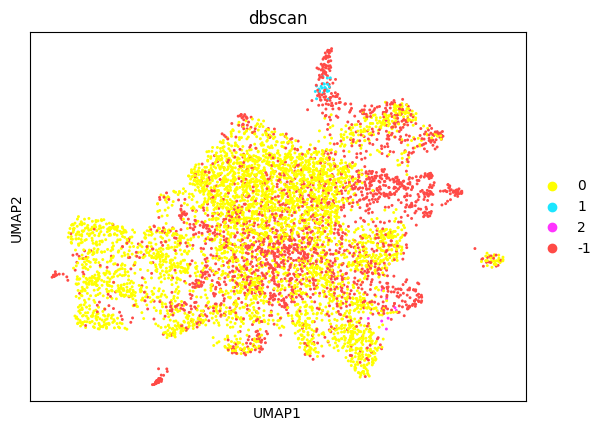

In [ ]:
# ── 1. PCA ───────────────────────────────────────────────────────────────────
sc.pp.pca(adata, n_comps=50)
X = adata.obsm["X_pca"]

# ── 2. DBSCAN ────────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=14, min_samples=10)
labels = dbscan.fit_predict(X)

# -1 = outliers non assignés à un cluster
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_outliers = (labels == -1).sum()
print(f"Clusters trouvés : {n_clusters}")
print(f"Cellules outliers : {n_outliers} ({n_outliers/len(labels)*100:.1f}%)")

adata.obs["dbscan"] = labels.astype(str)

# ── 3. Visualiser ────────────────────────────────────────────────────────────
sc.pl.umap(adata, color="dbscan")

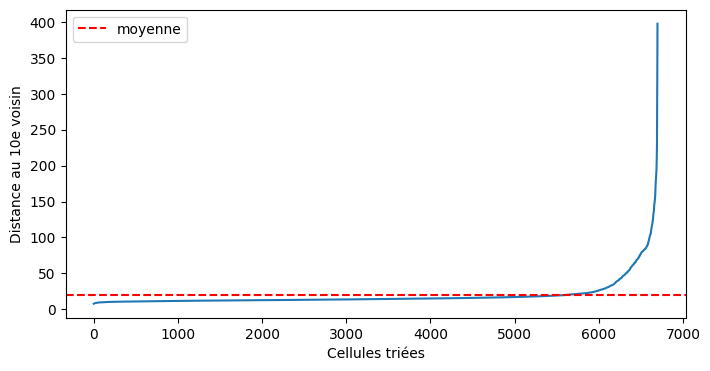

Moyenne : 19.77
Médiane : 14.22


In [ ]:
# k = min_samples que tu as choisi pour DBSCAN
k = 10
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X)
distances, _ = nn.kneighbors(X)

# distance au k-ème voisin, triée
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.ylabel(f"Distance au {k}e voisin")
plt.xlabel("Cellules triées")
plt.axhline(y=distances.mean(), color="r", linestyle="--", label="moyenne")
plt.legend()
plt.show()

print(f"Moyenne : {distances.mean():.2f}")
print(f"Médiane : {np.median(distances):.2f}")